# Notebook 2 - Clustering

This notebook continues from the preprocessing choices in `nb_1`. Reusable logic stays in `functions/clustering.py`; this notebook is for comparison tables, plots, and cluster interpretation.

In [18]:
import os
import sys
import warnings

sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
from functions.utils import load_raw_data
from functions.preprocessing import FEATURE_COLS, preprocessing, scale_features
from functions.clustering import (
    add_clusters,
    cluster_lift_profile,
    cluster_mean_profile,
    cluster_size_summary,
    compare_clustering_models,
    compare_dbscan,
    compare_kmeans_stability,
    compare_kmeans_inertia,
    export_cluster_profile,
    export_customer_clusters,
    fit_final_kmeans,
    plot_cluster_feature_heatmap,
    plot_metric_comparison,
    plot_pca_cluster_map,
    plot_umap_cluster_map,
    top_cluster_differences,
)

## Load Preprocessed Features

In [20]:
customer_info, customer_basket = load_raw_data()
customer_features = preprocessing(customer_info)
customer_scaled, scaler = scale_features(customer_features)

print(f'{customer_features.shape[0]:,} customers')
print(f'{len(FEATURE_COLS)} clustering features')
display(customer_scaled[FEATURE_COLS].head())

33,038 customers
21 clustering features


,age,is_female,household_size,has_loyalty_card,customer_tenure,distinct_stores_visited,typical_hour,percentage_of_products_bought_promotion,lifetime_total_distinct_products,number_complaints,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,0.03125,0.0,0.0,0.0,-0.714286,0.0,0.000,1.147251,0.461538,0.0,...,-0.350008,1.538609,-0.020252,-0.096317,-0.416981,-0.889505,-0.382116,-0.029743,0.311244,0.399106
1,-0.12500,0.0,-1.0,0.0,0.285714,-0.5,0.000,-0.262009,0.048951,-1.0,...,-0.130392,-0.228320,1.686147,0.440933,-0.574071,-0.870557,-0.744750,1.679631,0.530567,1.236579
2,0.00000,-1.0,-2.0,-1.0,1.428571,-0.5,-0.125,-0.498290,-0.293706,-1.0,...,0.450655,-0.654518,0.315733,-0.748057,-0.479881,1.554479,-0.175710,0.049021,-0.282499,-0.038382
3,-0.34375,-1.0,-2.0,0.0,-0.857143,-1.0,0.750,0.041426,-0.216783,1.0,...,-0.973212,0.007254,-0.330816,1.895790,1.739674,1.054119,1.681191,0.044439,8.226201,-0.173590
4,0.06250,-1.0,-2.0,0.0,-0.857143,-1.0,0.625,-0.154704,-0.818182,2.0,...,-1.668903,3.108581,-0.134922,0.237569,0.179075,0.331545,0.561586,-0.521282,3.167192,0.154859


## Candidate Model Comparison

K-Means and Ward hierarchical clustering are compared on the same reproducible sample. The final K-Means model is fitted on the full customer base.

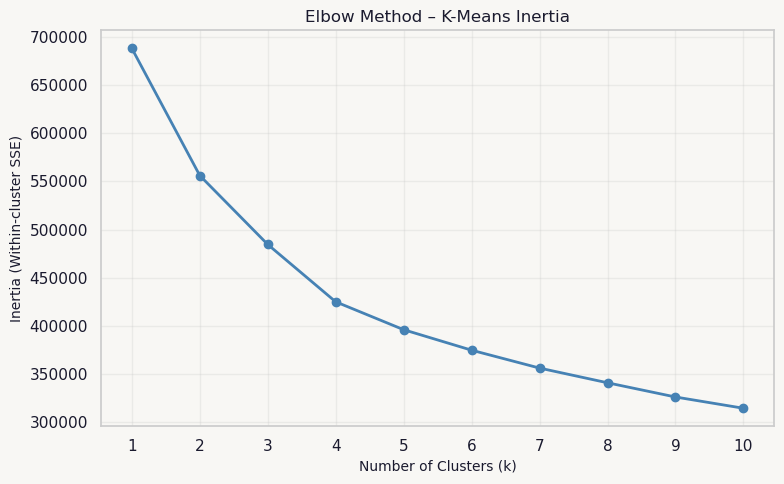

In [27]:
inertia_df = compare_kmeans_inertia(customer_scaled, FEATURE_COLS, k_range=range(1, 11))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(inertia_df['k'], inertia_df['inertia'], marker='o', linewidth=2, color='steelblue')
plt.title('Elbow Method – K-Means Inertia')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster SSE)')
plt.xticks(inertia_df['k'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

,model,k,fit_rows,n_clusters,n_metric_rows,silhouette,min_cluster_size,max_cluster_size,smallest_cluster_share,largest_cluster_share
0,kmeans,3,5000,3,5000,0.274393,463,3921,0.0926,0.7842
1,hierarchical_ward,3,5000,3,5000,0.254215,484,3975,0.0968,0.7950
2,kmeans,4,5000,4,5000,0.230277,450,3038,0.0900,0.6076
3,kmeans,5,5000,5,5000,0.212092,407,2795,0.0814,0.5590
4,kmeans,6,5000,6,5000,0.208935,163,2726,0.0326,0.5452
5,hierarchical_ward,4,5000,4,5000,0.186747,484,2807,0.0968,0.5614
6,hierarchical_ward,5,5000,5,5000,0.181630,162,2807,0.0324,0.5614
7,hierarchical_ward,6,5000,6,5000,0.179871,157,2807,0.0314,0.5614
8,kmeans,8,5000,8,5000,0.152700,160,1402,0.0320,0.2804
9,kmeans,7,5000,7,5000,0.148250,163,1531,0.0326,0.3062


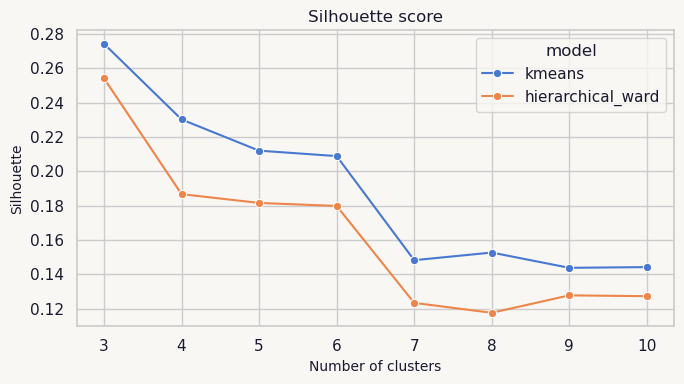

In [21]:
model_results = compare_clustering_models(
    customer_scaled,
    FEATURE_COLS,
    k_range=range(3, 11),
    sample_size=5000,
)

display(model_results)
plot_metric_comparison(model_results)

In [22]:
kmeans_stability = compare_kmeans_stability(
    customer_scaled,
    FEATURE_COLS,
    k_range=range(3, 11),
    seeds=range(5),
    sample_size=5000,
)

display(kmeans_stability)

,model,k,silhouette_mean,silhouette_std,smallest_cluster_share_min,largest_cluster_share_max
0,kmeans,3,0.274393,0.000000,0.0926,0.7842
1,kmeans,4,0.230247,0.000042,0.0898,0.6076
2,kmeans,5,0.211564,0.001361,0.0816,0.5580
3,kmeans,6,0.196960,0.028157,0.0330,0.5534
4,kmeans,9,0.155092,0.000184,0.0320,0.2318
5,kmeans,8,0.149221,0.008491,0.0316,0.2824
6,kmeans,7,0.147734,0.000302,0.0320,0.3062
7,kmeans,10,0.144269,0.001064,0.0320,0.1778


## DBSCAN Diagnostic

DBSCAN is used as an outlier/noise diagnostic, not as the main segmentation model.

In [6]:
dbscan_results = compare_dbscan(
    customer_scaled,
    FEATURE_COLS,
    eps_values=(1.5, 2.0, 2.5, 3.0, 3.5),
    min_samples_values=(10, 25, 50),
    sample_size=5000,
)

display(dbscan_results)

,model,eps,min_samples,fit_rows,n_clusters,n_metric_rows,silhouette,noise_share,min_cluster_size,max_cluster_size,smallest_cluster_share,largest_cluster_share
0,dbscan,2.5,50,5000,2,3427,0.390567,0.3146,261,3166,0.0522,0.6332
1,dbscan,1.5,10,5000,2,212,0.338749,0.9576,53,159,0.0106,0.0318
2,dbscan,2.0,10,5000,4,2304,0.257576,0.5392,20,2091,0.0040,0.4182
3,dbscan,2.0,50,5000,4,957,0.252276,0.8086,99,395,0.0198,0.0790
4,dbscan,2.5,25,5000,3,3772,0.202742,0.2456,52,3403,0.0104,0.6806
5,dbscan,2.5,10,5000,3,3996,0.188302,0.2008,77,3558,0.0154,0.7116
6,dbscan,2.0,25,5000,3,1541,0.103170,0.6918,21,1232,0.0042,0.2464
7,dbscan,3.5,10,5000,1,4794,NaN,0.0412,4794,4794,0.9588,0.9588
8,dbscan,3.5,25,5000,1,4729,NaN,0.0542,4729,4729,0.9458,0.9458
9,dbscan,3.5,50,5000,1,4676,NaN,0.0648,4676,4676,0.9352,0.9352


## Selected Candidate

`k=5` is kept as the current working candidate: it gives interpretable segments while avoiding the oversized single segment created by `k=3`.

In [8]:
selected_k = 5

labels, kmeans_model = fit_final_kmeans(
    customer_scaled,
    FEATURE_COLS,
    n_clusters=selected_k,
)

customer_clustered = add_clusters(customer_features, labels)
display(cluster_size_summary(customer_clustered))

,cluster,n_customers,customer_share
0,0,5427,0.1643
1,1,18400,0.5569
2,2,3550,0.1075
3,3,2971,0.0899
4,4,2690,0.0814


In [9]:
profile_cols = [
    'age',
    'is_female',
    'household_size',
    'has_loyalty_card',
    'customer_tenure',
    'distinct_stores_visited',
    'typical_hour',
    'percentage_of_products_bought_promotion',
    'lifetime_total_distinct_products',
    'number_complaints',
    'total_spend',
    'share_groceries',
    'share_electronics',
    'share_vegetables',
    'share_nonalcohol_drinks',
    'share_alcohol_drinks',
    'share_meat',
    'share_fish',
    'share_hygiene',
    'share_videogames',
    'share_petfood',
]

display(cluster_mean_profile(customer_clustered, profile_cols))
display(cluster_lift_profile(customer_clustered, profile_cols))
display(top_cluster_differences(customer_clustered, profile_cols, top_n=4))

,cluster,n_customers,customer_share,age,is_female,household_size,has_loyalty_card,customer_tenure,distinct_stores_visited,typical_hour,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,0,5427,0.1643,57.565,0.490,1.900,0.578,10.256,3.418,12.292,...,0.570,0.098,0.127,0.037,0.021,0.008,0.007,0.096,0.012,0.024
1,1,18400,0.5569,53.432,0.503,1.634,0.611,10.860,3.291,12.262,...,0.760,0.065,0.024,0.016,0.024,0.032,0.024,0.030,0.009,0.015
2,2,3550,0.1075,56.460,0.519,0.650,0.494,8.917,1.661,16.905,...,0.365,0.366,0.014,0.025,0.048,0.041,0.037,0.016,0.074,0.015
3,3,2971,0.0899,57.422,0.487,6.410,0.675,12.771,3.214,10.240,...,0.653,0.136,0.022,0.023,0.042,0.041,0.036,0.026,0.012,0.010
4,4,2690,0.0814,57.418,0.511,1.552,0.669,11.165,3.743,13.026,...,0.441,0.129,0.049,0.039,0.047,0.092,0.064,0.074,0.024,0.041


,age,is_female,household_size,has_loyalty_card,customer_tenure,distinct_stores_visited,typical_hour,percentage_of_products_bought_promotion,lifetime_total_distinct_products,number_complaints,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.044,0.976,0.953,0.959,0.954,1.079,0.972,0.423,0.698,0.713,...,0.876,0.853,3.040,1.625,0.723,0.237,0.270,2.245,0.648,1.319
1,0.969,1.002,0.819,1.012,1.010,1.039,0.970,1.192,0.986,1.040,...,1.168,0.571,0.574,0.690,0.804,0.926,0.897,0.711,0.516,0.823
2,1.024,1.035,0.326,0.818,0.830,0.524,1.337,0.846,0.713,1.152,...,0.561,3.198,0.341,1.119,1.629,1.161,1.354,0.373,4.101,0.812
3,1.042,0.970,3.213,1.118,1.188,1.015,0.810,0.676,1.974,1.051,...,1.003,1.185,0.537,1.006,1.430,1.168,1.318,0.611,0.640,0.572
4,1.042,1.019,0.778,1.109,1.039,1.182,1.030,1.412,1.005,1.050,...,0.678,1.129,1.178,1.693,1.595,2.643,2.359,1.722,1.326,2.287


,cluster,direction,feature,standardized_difference
0,0,below_average,share_meat,-0.882
1,0,below_average,share_fish,-0.820
2,0,below_average,percentage_of_products_bought_promotion,-0.650
3,0,below_average,total_spend,-0.614
4,0,above_average,share_vegetables,1.631
5,0,above_average,share_hygiene,1.301
6,0,above_average,share_nonalcohol_drinks,0.911
7,0,above_average,share_petfood,0.400
8,1,below_average,share_nonalcohol_drinks,-0.451
9,1,below_average,share_electronics,-0.383


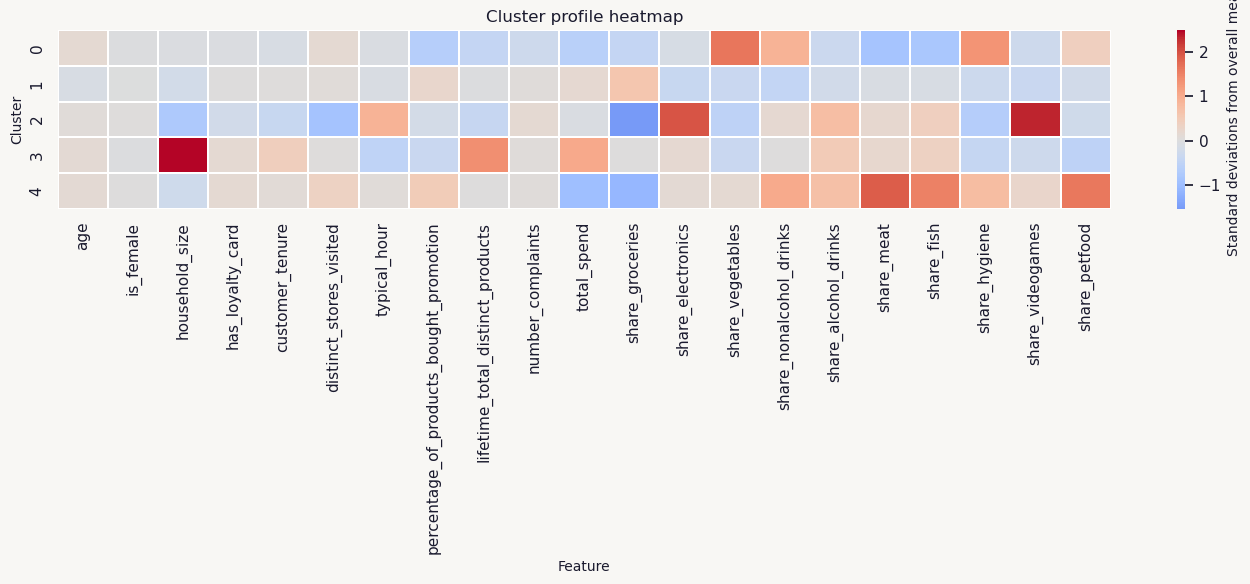

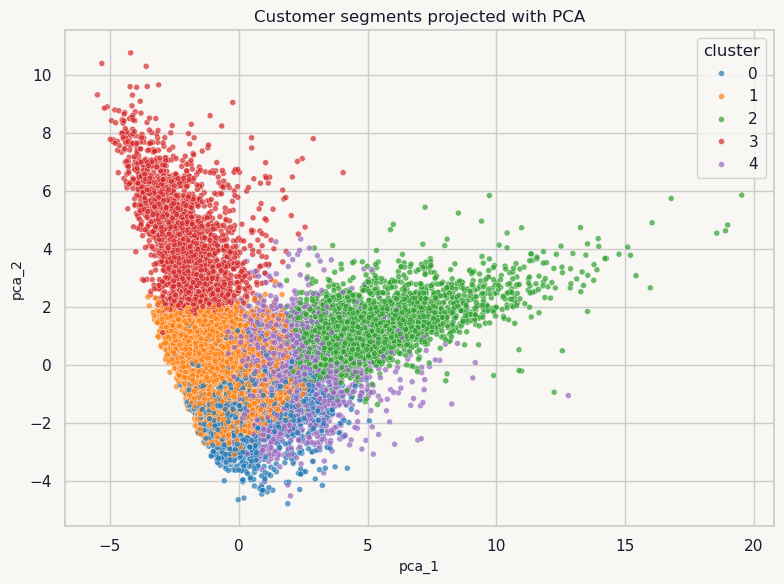

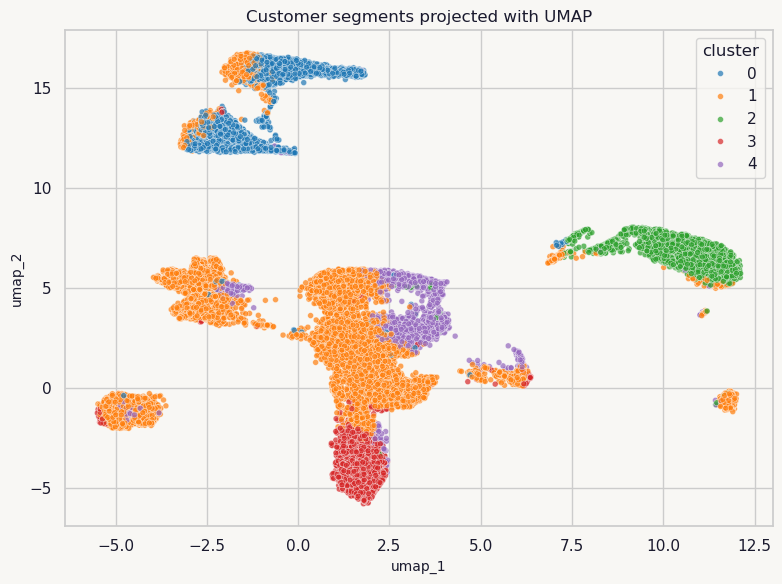

In [10]:
plot_cluster_feature_heatmap(customer_clustered, profile_cols)
plot_pca_cluster_map(customer_scaled, FEATURE_COLS, labels)
plot_umap_cluster_map(customer_scaled, FEATURE_COLS, labels)

## Export

In [ ]:
customer_clusters = export_customer_clusters(
    customer_clustered,
    output_path='../outputs/customer_clusters.csv',
)
cluster_profile = export_cluster_profile(
    customer_clustered,
    profile_cols,
    output_path='../outputs/cluster_profile.csv',
)

print(f'Exported {len(customer_clusters):,} customer assignments')
display(cluster_profile)